[二分搜索](./basic_algorithm/binary_search.md)  
[排序算法](./basic_algorithm/sort.md)  

### 二分搜索
二分查找（binary search）是一种基于分治策略的高效搜索算法。它利用数据的有序性，每轮缩小一半搜索范围，直至找到目标元素或搜索区间为空为止。也叫二分查找，时间复杂度O(log n)


#### 二分查找的三个模版(优先选用模版3)
你在网上看到的 99% 的二分查找问题会归结于这 3 个模板中的一个。有些问题可以使用多个模板来实现，但是当你做更多的练习时，你会注意到一些模板比其他模板更适合某些问题。

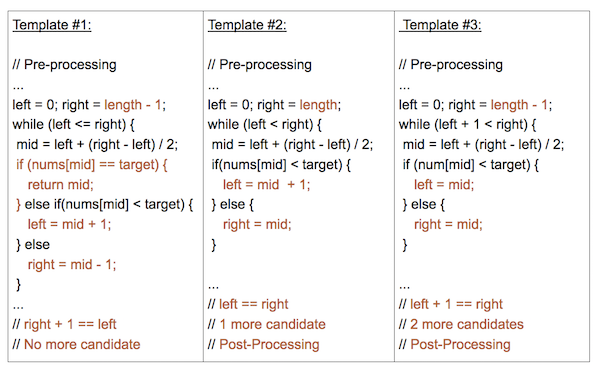


图中标注了left 和 right 位置的关系  
模板 #1 和 #3 是最常用的，几乎所有二分查找问题都可以用其中之一轻松实现。模板 #2 更 高级一些，用于解决某些类型的问题。

三个模板在那种情况下使用？
- 模板1：循环结束后，left 跑到了 right 的右边，很奇怪的现象, 且left -1 = right。right多退了一步  
- 模板2：循环结束后，left = right, 所以只需要一个与目标值比较就好了  
- 模板3：循环结束后，left < right, 且left +1 = right。这是循环条件决定的  


模版详细分析：https://leetcode.cn/leetbook/read/binary-search/xewjg7/


In [ ]:
from typing import List
#  模版python 代码
# 模版1
class Solution:
    def search(self, nums: List[int], target: int) -> int:
        left, right = 0, len(nums) - 1
        while left <= right:
            mid = left + (right - left) // 2
            if nums[mid] == target:
                return mid
            elif nums[mid] < target:
                left = mid + 1 
            else:
                right = mid - 1
        return -1
    
# 模版2
class Solution:
    def search(self, nums: List[int], target: int) -> int:
        left, right = 0, len(nums)-1
        while left < right:
            mid = left + (right - left) // 2
            if nums[mid] < target:
                left = mid + 1
            else:
                right = mid
        return left if nums[left] == target else -1
    
# 模版3
class Solution:
    def search(self, nums: List[int], target: int) -> int:
        left, right = 0, len(nums)-1
        while left+1 < right:
            mid = left + (right - left) // 2
            if nums[mid] < target:
                left = mid
            else:
                right = mid
        if nums[left] == target:
            return left
        elif nums[right] == target:
            return right
        else:
            return -1

    


### 模版2的坑：
最后判断用的left,不是mid  
得到的left = right 是第一个大于target的值，也是要插入的位置，但是呢，这不如模版1，可以获得  left 是第一个大于 target 的索引，right 是最后一个小于 target 的索引，这个right就有用了。  
变体：模版2搜索失败，left-1  

In [ ]:
# 查找右边界模版
def search(a,target):
    l,r = 0,len(a)-1
    while l<r:
        mid = l + (r-l) // 2 +1
        if a[mid] <= target:
            # a[mid] == target 是l往右移动
            l = mid
        else:
            r = mid-1
    if a[l] != target:
        range[1] = range[0]
    else:
        range[1] = l

### 34. 在排序数组中查找元素的第一个和最后一个位置
>给定一个包含 n 个整数的排序数组，找出给定目标值 target 的起始和结束位置。如果目标值不在数组中，则返回[-1, -1]

- 思路：核心点就是找第一个 target 的索引，和最后一个 target 的索引，所以用两次二分搜索分别找第一次和最后一次的位置，下面是使用模板 3 +模板 1 的解法

In [36]:
def searchRange(nums,target):
    if not nums:
        return [-1,-1]
    range = [-1,-1]
    # 模版3，找元素的第一个下标
    left,right = 0,len(nums)-1
    while left +1 < right:
        mid = left + (right-left) // 2
        if nums[mid] < target:
            left = mid
        else:
            right = mid
    if nums[left] == target:
        range[0] = left
    elif nums[right] == target:
        range[0] = right
    else:
        return range
    
    left,right = 0,len(nums)-1
    # 模版1，继续找元素的最后一个下标
    while left <= right:
        mid = left + (right-left) // 2
        if nums[mid] == target:
            range[1] = mid
            left = mid + 1 
        elif nums[mid] < target:
            left = mid + 1 
        else:
            right = mid - 1
    
    return range
    
# nums = [5,7,7,8,8,10]
nums= [1,2,3]
target = 2

searchRange(nums,target)

[1, 1]

In [ ]:
def searchRange(nums,target):
    range = [-1,-1]
    left,right = 0,len(nums)-1
    # 找第一个元素的下标
    while left +1 < right:
        mid = left + (right-left) // 2
        if nums[mid] < target:
            left = mid
        else:
            right = mid
    if nums[left] == target:
        range[0] = left
    elif nums[right] == target:
        range[0] = right
    else:
        return range
    
    left,right = 0,len(nums)-1
    # 开始找最后一个元素的下标
    while left +1 < right:
        mid = left + (right-left) // 2
        if nums[mid] <= target:
            left = mid
        else:
            right = mid
    if nums[left] == target:
        range[1] = left
    else:
        range[1] = right
    return range
nums = [5,7,7,8,8,8,8,10]
target = 7

searchRange(nums,target)

O(N) 是1+1+1...+1,N个1  
O(log2N) 是    
O(N) 优于O(log2N)吗？    
理论上，除了 𝑁=1 这种极小规模特例外，O(logN) 永远优于 O(N)。  
O(N) ≈ 100 次常数操作  
O(log₂N) ≈ log₂(100) ≈ 6.64 次  
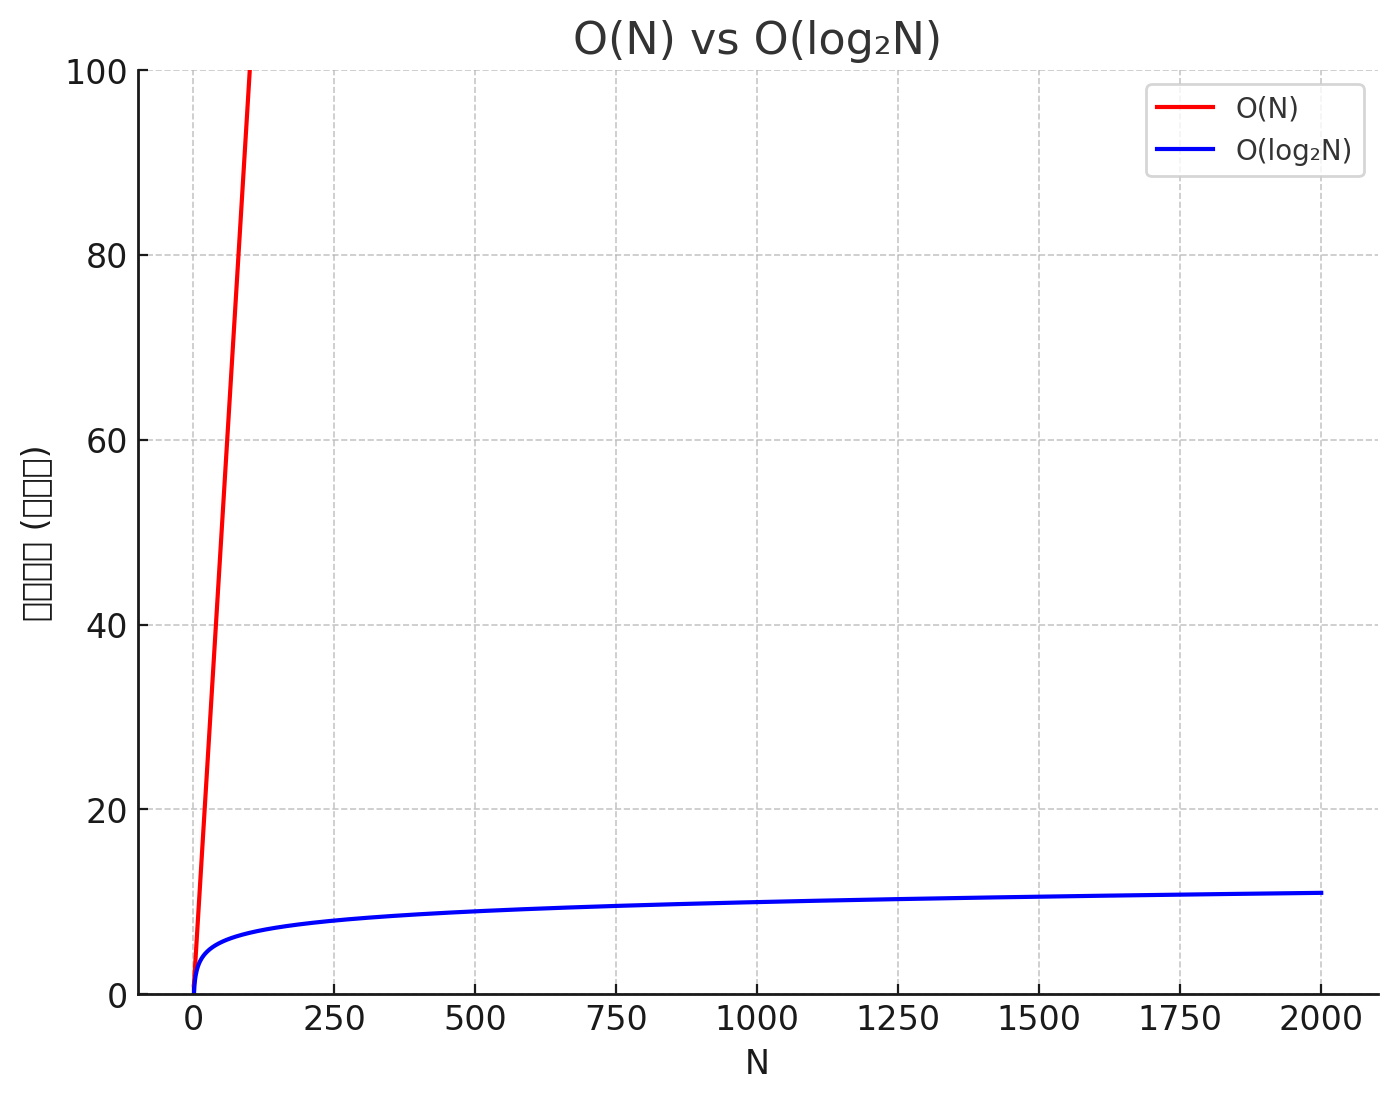


Python 的作用域规则  
Python 中 while 循环、for 循环里的变量不会限制在循环体内部，它们的作用域是整个函数体。  
所以循环结束后，你依然可以访问 row。  

In [15]:
bool(1)

True

In [16]:


def searchMatrix(matrix, target):

    if not len(matrix) or not len(matrix[0]):
        return False
    
    # 不需要找了
    if target > matrix[-1][-1] or target < matrix[0][0]:
        return False
    
    # 定位行数
    l ,r = 0, len(matrix)-1
    while l <= r:
        mid = l + (r-l) // 2
        if matrix[mid][0] == target:
            return True
        elif matrix[mid][0] < target:
            l = mid +1
        else:
             r = mid-1
             
    row = r     

    # 定位列数
    l ,r = 0, len(matrix[row])-1
    while l <= r:
        mid = l + (r-l) // 2
        if matrix[row][mid] == target:
            return True
        elif matrix[row][mid] <  target:
            l = mid + 1
        else:
            r = mid - 1
            
    return False
    
target = 22
matrix = [[1,3,5,7],[10,11,16,20],[23,30,34,60]]
searchMatrix(matrix, target)

False

In [18]:
# 使用二分搜索，当中间元素大于最右侧元素时意味着拐点即最小元素在右侧，否则在左侧
def findMin(nums):
    l,r = 0,len(nums)-1
    while l<r:
        mid = l +(r - l) // 2
        if nums[mid] > nums[r]:
            l = mid+1
        else:
            r = mid
    return nums[l]

In [19]:
def findMin(nums):
    l,r = 0,len(nums)-1
    while l<r:
        mid = l +(r - l) // 2
        if nums[mid] > nums[r]:
            l = mid+1
        elif nums[mid] < nums[r] or nums[mid] != nums[l]:
            r = mid
        else: # nums[l] == nums[mid] == nums[r]
            l += 1
            
    return nums[l]

In [21]:
def search(nums, target):
    pass

In [29]:
# 思路：元素各不相同，可以通过nums[mid] 和 nums[left] 得出左半区有序还是右半区有序

def search(nums, target):
    l,r = 0,len(nums)-1
    while(l <= r):
        mid = l + (r-l) // 2
        if nums[mid] == target:
            return mid
        elif nums[mid] > target:
            # 已经满足条件target 比中间值小
            if nums[l] > target and nums[mid] > nums[l]:
                l = mid +1
            else:
                r = mid - 1
        else: # target 比中间值大 那就看比target大的数的分布
            # 仅仅凭借target > nums[r], 还不能确定落在了左边区间，加上 右区间有序，就可以了
            if nums[r] < target and nums[mid] < nums[l]:
                r = mid -1
            else:
                l = mid +1
    return -1

# nums = [3,4,5,6,7,1,2]
nums = [6,7,1,2,3,4,5]

target = 5
search(nums, target)

6

In [46]:
def search(nums, target) -> int:
    l, r = 0, len(nums)-1
    while l <= r:
        mid = l + (r -l) //2
        if target == nums[mid]:
            return mid
        elif target < nums[mid]:
            if target <  nums[l] and nums[mid] >  nums[r]:
                l = mid +1
            else:
                r = mid -1
        else:
            if target > nums[r] and nums[mid] <  nums[l]:
                r = mid -1
            else:
                l =mid +1
    return -1

# nums = [3,4,5,6,7,1,2]
# nums = [6,7,1,2,3,4,5]
nums =[4,5,6,7,0,1,2]

target = 0
search(nums, target)

4

In [ ]:
# 加了一个重复值处理
def search(nums, target) -> int:
    l, r = 0, len(nums)-1
    while l <= r:
        if nums[l] == nums[r] and nums[l] != target:
            l += 1
            r -= 1
            continue
        mid = l + (r -l) //2
        if target == nums[mid]:
            return True
        elif target < nums[mid]:
            if target <  nums[l] and nums[mid] >  nums[r]:
                l = mid +1
            else:
                r = mid -1
        else:
            if target > nums[r] and nums[mid] <  nums[l]:
                r = mid -1
            else:
                l =mid +1
    return False

In [58]:
import math
# 向math.ceil取整,ceil向正无穷取整
piles = [3,6,7,11]






[1, 1, 2, 2]

In [68]:
# piles：一大堆
# math.ceil 是 Python 数学库 math 里的一个函数，意思是 向上取整。
def minEatingSpeed(piles,h):
    # 那如果h=len(piles),最小速度就是max(piles),如果h>len(piles),最小速度可以更小，那么初始化速度的边界是1到max(piles)
    l,r = 1, max(piles)
    while l < r:
        mid = l + (r-l) // 2
        print(mid)
        # 以当前速度能吃完所有香蕉吗？取负号的原因是向下取整数值变大，也可以处理成正数向上取整
        if sum([ math.ceil(pile / mid) for pile in piles])<= h:
            # 按照当前速度mid,吃得完，要加速
            r =mid
        else:
            l = mid + 1
            
    return l
    
piles = [3,6,7,11]
h = 8

minEatingSpeed(piles,h)

6
3
5
4


4

[排序算法](./basic_algorithm/sort.md)

### 十大排序算法：
https://www.cnblogs.com/onepixel/p/7674659.html

### 归并排序
- 时间复杂度为 𝑂(nlog2n)、非自适应排序
- 空间复杂度为 𝑂(n)、非原地排序
- 稳定排序

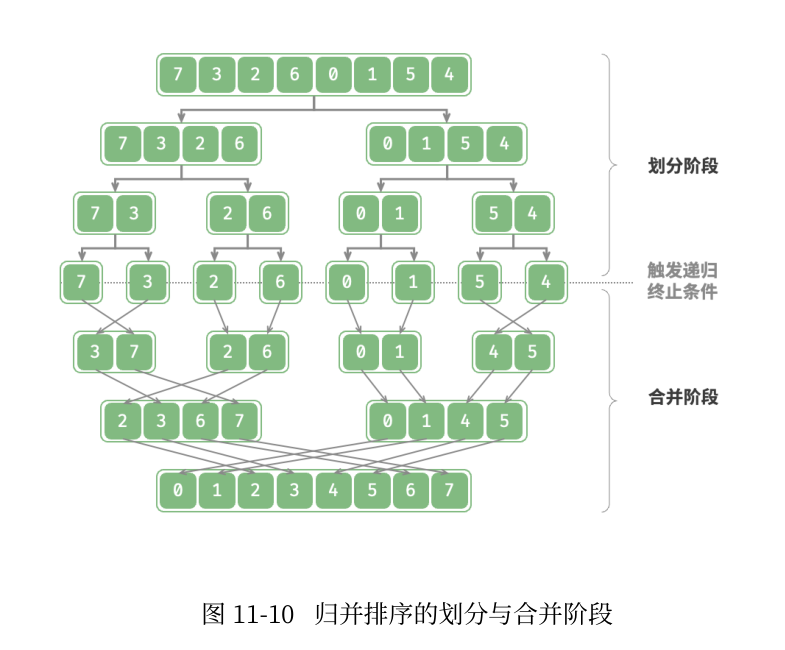  
归并排序：findMid(list),mergeList(list1,list2)

In [1]:
nums1 = [2,3,6,7,18,19,20]
nums2 = [0,1,4,5,6,9]
nums = [7, 6, 8, 5, 2, 1, 3, 4, 0, 9]


def findMid(nums):
        # 数组比较简单
        # 链表有点复杂
        return len(nums) // 2
    
def mergeNums(nums1,nums2):
    # 合并两个有序数组
    result = []
    index1 = index2 = 0
    while index1 < len(nums1) and index2 < len(nums2):
        if nums1[index1] > nums2[index2]:
            result.append(nums2[index2])
            index2 += 1
        else:
            result.append(nums1[index1]) 
            index1 += 1
    result += nums2[index2:] if index1 == len(nums1) else  nums1[index1:]
    
    return result

def mergeSort(nums):
    # 递归
    if len(nums) < 2:
        return nums[:]
    
    mid = findMid(nums)
    left = mergeSort(nums[:mid])
    right = mergeSort(nums[mid:])
    return mergeNums(left,right)
    
mergeSort(nums) 

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

partition, 分治

### 快排
- 时间复杂度为 𝑂(nlog2n)、非自适应排序
- 空间复杂度为 𝑂(n)、原地排序
- 非稳定排序


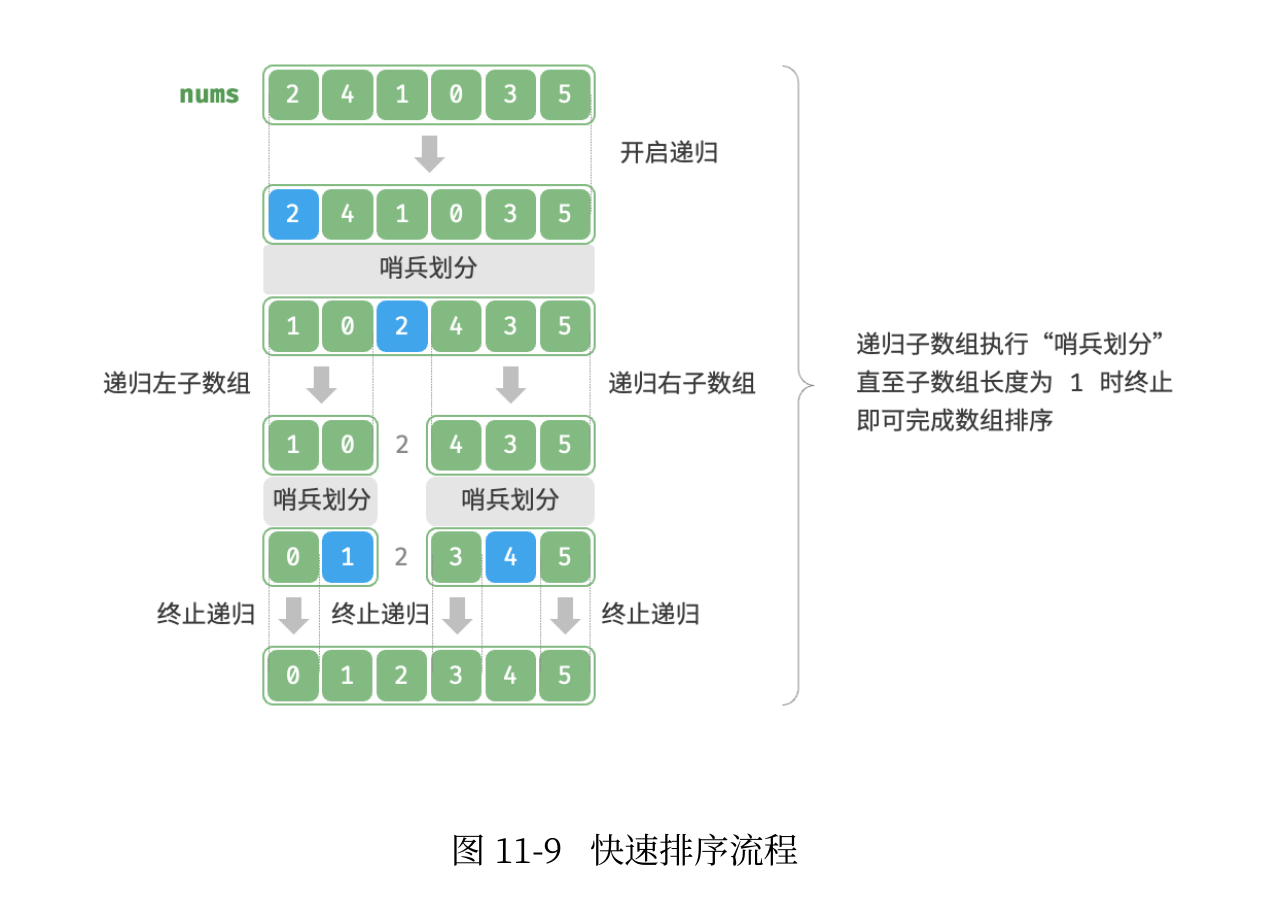  

哨兵划分    

快速排序的核心操作是“哨兵划分”，其目标是：选择数组中的某个元素作为“基准数”，将所有小于基准数的元素移到其左侧，而大于基准数的元素移到其右侧。

In [13]:
# pivot 支点
def partition(nums, left, right):
    "哨兵划分"
    i,j = left,right  # 以nums[left] 为基准数
    while i< j:
        while i < j and nums[j] >= nums[left]:  #从右向左找首个小于基准数的元素
            j -= 1
        while i < j and nums[i] <= nums[left]:  #从左向右找首个大于基准数的元素
            i += 1
        nums[i],nums[j] = nums[j],nums[i]     # 交换这两个元素
        
    nums[i] , nums[left]  = nums[left], nums[i]   # 将基准数交换到两子数组的分界线
    return i  # 返回基准数的索引
# nums = [2,4,1,0,3,5]
# partition(nums, 0, 5)
def quickSort(nums,left,right):
    if left >= right:
        return
    pivot = partition(nums, left, right)  # 哨兵划分
    quickSort(nums,left,pivot-1)
    quickSort(nums,pivot+1,right)
    # print(nums)
    

nums = [7, 6, 8, 5, 2, 1, 3, 4, 0, 9, 10]
quickSort(nums,0,len(nums)-1)
nums

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

### 堆排序
- 时间复杂度为 𝑂(nlog2n)、非自适应排序
- 空间复杂度为 𝑂(1)、原地排序
- 非稳定排序

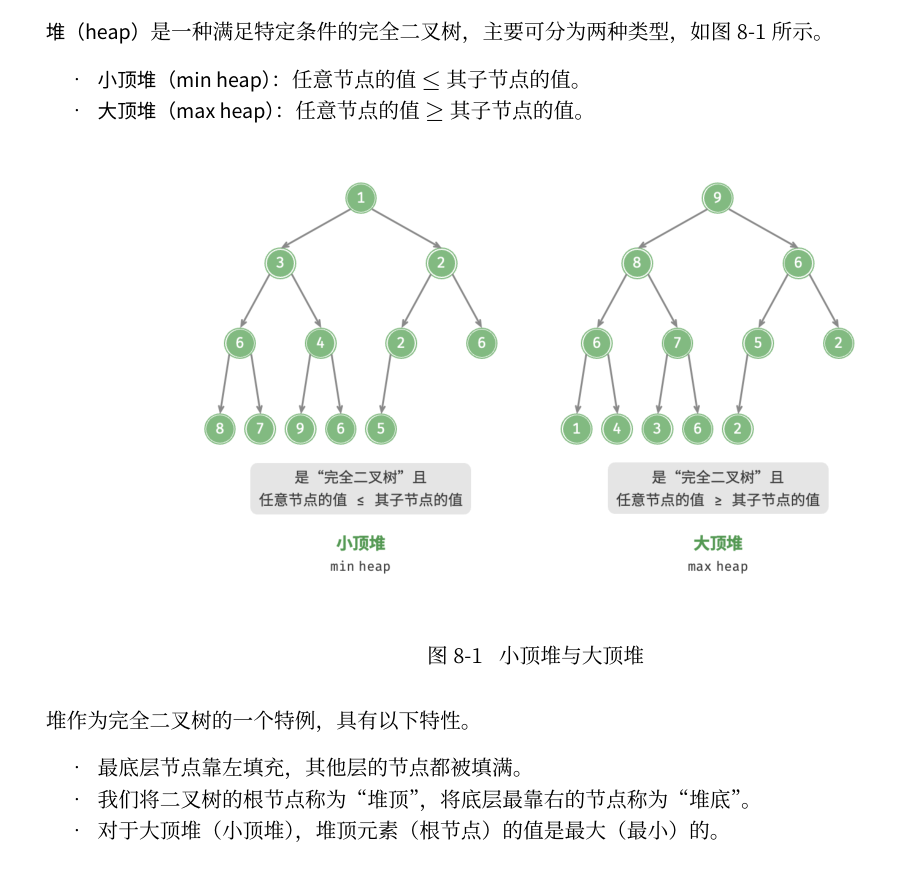  



In [74]:
import heapq
def sift_down(nums, n, i):
    # 堆化操作
    """ 堆的长度为 n ，从节点 i 开始，从顶至底堆化"""
    while True:
        l,r  = 2*i +1, 2*i +2
        ma = i # 判断节点 i, l, r 中值最大的节点，记为 ma
        if l < n and nums[l] > nums[ma]:
            ma = l
        if r < n and nums[r] > nums[ma]:
            ma = r
        if ma==i:# 若节点 i 最大或索引 l, r 越界，则无须继续堆化，跳出
            break
        nums[i], nums[ma] = nums[ma], nums[i]# 交换两节点
        i = ma  # 循环向下堆化
        
def heapSort(nums):
    # 建立堆
    N = len(nums)
    for i in range(N//2 -1, -1, -1):  # 数组表示的堆的自底向上的堆化公式  
        sift_down(nums,len(nums),i)
    # 堆化成功后
    for i in range(N-1,0,-1):
        nums[i], nums[0] = nums[0], nums[i]
        sift_down(nums,i,0)
        
    return nums

nums = [7, 6, 8, 5, 2, 1, 3, 4, 0, 9, 10]
heapSort(nums)
nums

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

nums = [-x for x in nums]
heapq.heapify(nums)
print(nums)
nums = [-x for x in nums]
print(nums)
[10, 9, 8, 5, 7, 1, 3, 4, 0, 6, 2]
[10, 9, 8, 5, 7, 1, 3, 4, 0, 6, 2]
堆化效果是一样的啊。深拷贝和浅拷贝的问题吧，不深究了。




### range 的倒序index 技巧
range(start, stop, step) 的含义是：从 start 开始，以 step 为步长  
停止条件
- step 正时：< stop
- step 负时：> stop

In [20]:
for i in range(10,0,-1):
    print(i)

10
9
8
7
6
5
4
3
2
1


### 215. 数组中的第K个最大元素
>给定。。。

- 思路1：用最小堆，遍历一遍数组即可
- 思路2：用排序算法，如快排，排序后再返回


In [62]:
nums = [3,2,1,5,6,4]
k = 2
sorted(nums,reverse=True)[k-1]
# nums[2]

5

In [68]:
import heapq
nums = [3,2,1,5,6,4]
nums = [-x for x in nums]
heapq.heapify(nums)
nums = [-x for x in nums]
nums

[6, 5, 4, 3, 2, 1]

In [11]:
import random

def findKthLargest(nums,k):
    # 快速选择
    def partition(left,right):
        # 哨兵划分
        i,j = left,right
        # 基准数优化一定要做的
        pivot_idx = random.randint(left, right)
        pivot = nums[pivot_idx]
        while i<j:
            while i<j and nums[j] >= pivot:
                j -= 1
            while i<j and nums[i] <= pivot:
                i += 1
            if i<j:
                nums[i],nums[j] = nums[j], nums[i]
        nums[i],pivot = pivot,nums[i]
        return i
    # 线性遍历
    left, right = 0, len(nums) - 1
    target = len(nums)-k
    while True:
        pivot_index = partition(left,right)
        if pivot_index == target:
            return nums[target]
        elif pivot_index < target:
            left = pivot_index + 1
        else:
            right = pivot_index-1
nums = [3,2,3,1,2,4,5,5,6]
k = 4
print("结果：",findKthLargest(nums,k))
nums

结果： 4


[3, 2, 3, 1, 3, 4, 5, 5, 6]